# Geoprocessing Techniques Project

This notebook explores the spatial distribution of shellfish aquaculture leases in North Carolina using county boundaries and public coastal access locations.

In [87]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [88]:
counties = gpd.read_file("../week07/data/nc_counties.geojson")
leases = gpd.read_file("../week07/data/nc_shellfish_leases.geojson")
access = gpd.read_file("../week07/data/nc_coastal_access.geojson")

Counties CRS: EPSG:4326
Leases CRS: EPSG:4326
Access CRS: EPSG:4326
Counties: (27, 10)
Leases: (869, 24)
Access: (906, 43)


<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

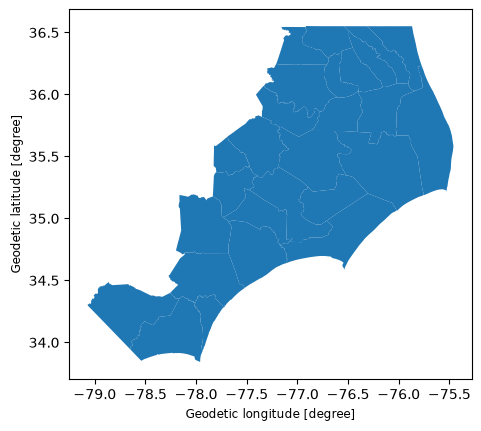

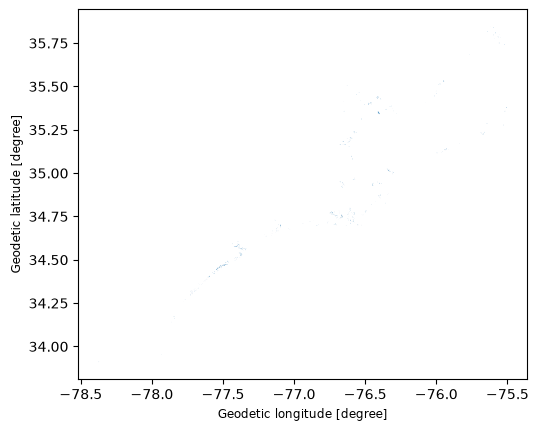

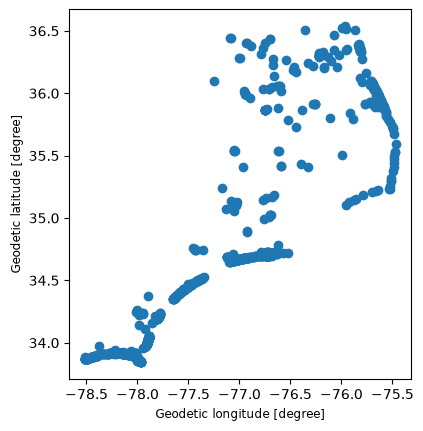

In [89]:
print("Counties CRS:", counties.crs)
print("Leases CRS:", leases.crs)
print("Access CRS:", access.crs)

print("Counties:", counties.shape)
print("Leases:", leases.shape)
print("Access:", access.shape)

counties.plot()
leases.plot()
access.plot()

The three maps above show the original spatial datasets used in this project:

- North Carolina coastal county boundaries
- Shellfish lease locations
- Public coastal access sites

These datasets provide the input layers for the geoprocessing analyses I do below.

## **Layer 1: Shellfish Leases Assigned to Counties**

My first analysis uses a spatial join to determine which North Carolina county contains each shellfish lease. I created representative points from the lease polygons and spatially joined them to county boundaries. The county assignments were then added back to the original lease polygons.

In [90]:
leases.columns

Index(['OBJECTID', 'ProductNbr', 'Assoc_ID', 'Owner', 'Bus_Agent', 'County',
       'WB_Name', 'waterbodycode', 'Type', 'Status', 'A_Granted', 'acreage',
       'LastUpdate', 'StatusDt', 'EffectiveDt', 'Date_Ver', 'ExpirationDt',
       'Term_Date', 'GlobalID', 'ProductID', 'ViewLink', 'PropAcres',
       'ParticipantID', 'geometry'],
      dtype='str')

In [91]:
counties.columns

Index(['objectid_12', 'county', 'fips', 'rec_survey', 'ncgs_url', 'ck_date',
       'area_mi_sq', 'st_area(shape)', 'st_perimeter(shape)', 'geometry'],
      dtype='str')

In [92]:
lease_points = leases[["OBJECTID", "geometry"]].copy()
lease_points["geometry"] = lease_points.geometry.representative_point()

point_join = gpd.sjoin(lease_points, counties[["county", "geometry"]], how="left", predicate="within")

leases_by_county = leases.merge(point_join[["OBJECTID", "county"]], on="OBJECTID", how="left", validate="one_to_one")

In [93]:
leases_by_county["county"].isna().sum()

np.int64(0)

In [94]:
(leases_by_county["County"] == leases_by_county["county"]).value_counts()

True     868
False      1
Name: count, dtype: int64

In [95]:
leases_by_county[leases_by_county["County"] != leases_by_county["county"]][["County", "county", "geometry"]]

,County,county,geometry
532,Pamlico,Pender,"POLYGON ((-77.61635 34.38853, -77.61659 34.389..."


The initial spatial join produced 870 records because one lease polygon intersected two counties. To resolve this, I used representative points to assign each lease to a single county while preserving the original polygon geometries. The corrected spatial join assigned all 869 shellfish leases to counties without duplicate records. One lease originally listed in Pamlico County was spatially assigned to Pender County, suggesting a possible discrepancy in the source data.

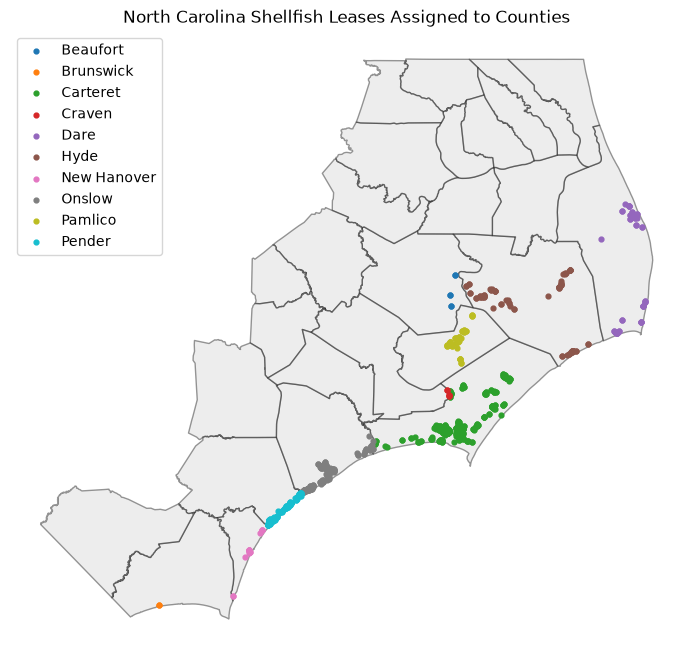

In [96]:
leases_plot = leases_by_county.copy() # making copy for plotting to avoid changing original data

leases_plot["geometry"] = leases_plot.geometry.representative_point()

fig, ax = plt.subplots(figsize=(10, 8))

counties.plot(ax=ax, facecolor="lightgray", edgecolor="black", alpha=0.4)

# Lease locations, colored by the county assigned from the spatial join
leases_plot.plot(ax=ax, column="county", categorical=True, legend=True, markersize=12)

ax.set_title("North Carolina Shellfish Leases Assigned to Counties")
ax.set_axis_off()

plt.show()


This map shows the results of the spatial join between shellfish lease polygons and county polygons. I assigned each shellfish lease to the county that it intersects. Because the individual lease polygons are very small compared with the county boundaries, I used representative points for visualization. The colors represent the county assigned to each lease through the spatial join. The spatial join successfully assigned all shellfish leases to a county.

## **Layer 2: Coastal access sites in counties that contain shellfish leases**

Using the results of Layer 1, I identified the North Carolina counties that contain shellfish leases. I then used a clip operation to create a new layer containing only public coastal access sites located within those counties.

In [97]:
lease_county_names = leases_by_county["county"].unique()

lease_county_names

<StringArray>
[     'Onslow',    'Carteret',      'Pender',        'Hyde',     'Pamlico',
        'Dare', 'New Hanover',    'Beaufort',   'Brunswick',      'Craven']
Length: 10, dtype: str

In [98]:
counties_with_leases = counties[counties["county"].isin(lease_county_names)]

len(counties_with_leases)



10

In [99]:
access_in_lease_counties = gpd.clip(access, counties_with_leases)

print("Original Access Sites:", len(access))
print("Access Sites in Counties with Leases:", len(access_in_lease_counties))

Original Access Sites: 906
Access Sites in Counties with Leases: 799


In [100]:
access_in_lease_counties.head()

,ACCESS_ID,OBJECTID,PLACE,ACCESS_LOC,LOCL_SPONS,CAMA_SIGN,PARKING,DUNE_WALK,OVERLOOK,HAND_DUNE,...,BWC_Info,PaidParkURL,WaterAccessTYPE,BeachMat,Land_Status,NEAR_FID,NEAR_DIST,ACCESSIBILITY_NOTES,LIFEGUARDS,geometry
193,Public Beach Access #39,196,Bald Head Island,Station House Way,Bald Head Island,No,20.0,Y,NaN,No,...,https://live-village-bhi.pantheonsite.io/depar...,n/a,Ocean,NaN,Municipality,836.0,791.568243,NaN,NaN,POINT (-77.96146 33.84549)
488,Public Beach Access #36,493,Bald Head Island,In front of what is known as Captain Charlie's...,,No,12.0,Y,No,No,...,https://live-village-bhi.pantheonsite.io/depar...,n/a,Ocean,NaN,Municipality,490.0,600.480991,NaN,NaN,POINT (-77.96696 33.84608)
485,Public Beach Access #35,490,Bald Head Island,Immediately on the North side of Loggerhead T...,Bald Head Island,No,12.0,Y,No,No,...,https://live-village-bhi.pantheonsite.io/depar...,n/a,Ocean,NaN,Municipality,835.0,451.070193,NaN,NaN,POINT (-77.9688 33.84666)
828,Public Beach Access #34,835,Bald Head Island,Off of S. Bald Head Wynd near Loggerhead Trail,Bald Head Island,Unknown,NaN,Y,N,N,...,https://live-village-bhi.pantheonsite.io/depar...,n/a,Ocean,NaN,Municipality,488.0,110.631440,NaN,NaN,POINT (-77.97014 33.84721)
483,Public Beach Access #34,488,Bald Head Island,Directly across from 995 Loggerhead Trail on S...,,No,6.0,Y,No,No,...,https://live-village-bhi.pantheonsite.io/depar...,n/a,Ocean,NaN,Municipality,835.0,110.631440,NaN,NaN,POINT (-77.97044 33.84737)


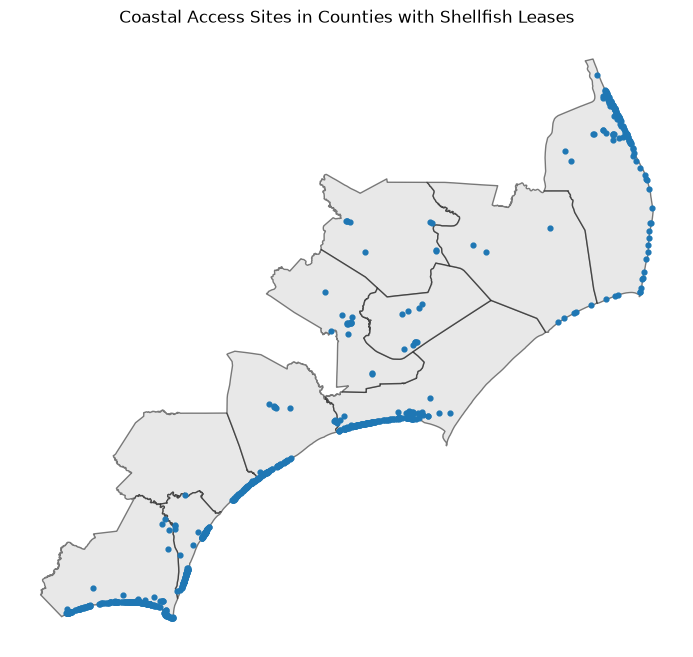

In [101]:
fig, ax = plt.subplots(figsize=(10, 8))

counties_with_leases.plot(ax=ax, facecolor="lightgray", edgecolor="black", alpha=0.5)

access_in_lease_counties.plot(ax=ax, markersize=12)

ax.set_title("Coastal Access Sites in Counties with Shellfish Leases")
ax.set_axis_off()

plt.show()

This map shows public coastal access sites located within counties that contain shellfish leases. Using the results from Layer 1, I selected the counties containing shellfish leases. I then clipped the coastal access dataset to those county boundaries. The clip reduced the coastal access dataset from 906 total sites to 799 sites located within the 10 counties containing shellfish leases.

## **Layer 3: Coastal Access Sites Within 5 km of Shellfish Leases**

This analysis identifies public coastal access sites that are located within 5 kilometers of shellfish lease areas. I projected the shellfish lease layer to a coordinate system that uses meters, buffered by 5,000 meters, and then used it to identify nearby coastal access sites.


In [102]:
leases_proj = leases.to_crs(epsg=32119) # NAD83
access_proj = access_in_lease_counties.to_crs(epsg=32119)
counties_proj = counties.to_crs(epsg=32119)

In [103]:
lease_buffer = leases_proj.copy()
lease_buffer["geometry"] = lease_buffer.geometry.buffer(5000) 
lease_buffer_area = lease_buffer.dissolve()

In [104]:
access_near_leases = gpd.clip(access_proj, lease_buffer_area)

print("Access Sites in Counties with Leases:", len(access_in_lease_counties))
print("Access Sites within 5 km of Leases:", len(access_near_leases))

Access Sites in Counties with Leases: 799
Access Sites within 5 km of Leases: 377


In [105]:
access_near_leases.head()

,ACCESS_ID,OBJECTID,PLACE,ACCESS_LOC,LOCL_SPONS,CAMA_SIGN,PARKING,DUNE_WALK,OVERLOOK,HAND_DUNE,...,BWC_Info,PaidParkURL,WaterAccessTYPE,BeachMat,Land_Status,NEAR_FID,NEAR_DIST,ACCESSIBILITY_NOTES,LIFEGUARDS,geometry
56,Leland Access,59,Ocean Isle Beach,E First St & Leland St,,Yes,25.0,Y,No,No,...,https://www.oibgov.com/pview.aspx?id=20773&cat...,n/a,Ocean,NaN,Municipality,566.0,1098.909707,NaN,NaN,POINT (663352.186 15892.933)
561,Goldsboro Access,566,Ocean Isle Beach,East First St & Goldsboro St,,Yes,21.0,Y,No,No,...,https://www.oibgov.com/pview.aspx?id=20773&cat...,n/a,Ocean,NaN,Municipality,59.0,1098.909707,NaN,NaN,POINT (663670.669 15996.659)
559,Chadbourn Access,564,Ocean Isle Beach,East First Street and Chadbourn Street,Ocean Isle Beach,Yes,25.0,Y,No,No,...,https://www.oibgov.com/pview.aspx?id=20773&cat...,n/a,Ocean,NaN,Municipality,562.0,1098.349334,NaN,NaN,POINT (663991.394 16093.999)
557,Winnabow Access,562,Ocean Isle Beach,East First Street and Winnabow Street,,Yes,25.0,Y,No,No,...,https://www.oibgov.com/pview.aspx?id=20773&cat...,n/a,Ocean,NaN,Municipality,564.0,1098.349334,NaN,NaN,POINT (664311.175 16193.075)
555,Greensboro Access,560,Ocean Isle Beach,East First Street and Greensboro Street,,Yes,NaN,Y,No,No,...,https://www.oibgov.com/pview.aspx?id=20773&cat...,n/a,Ocean,NaN,Municipality,557.0,840.962498,NaN,NaN,POINT (664639.157 16283.058)


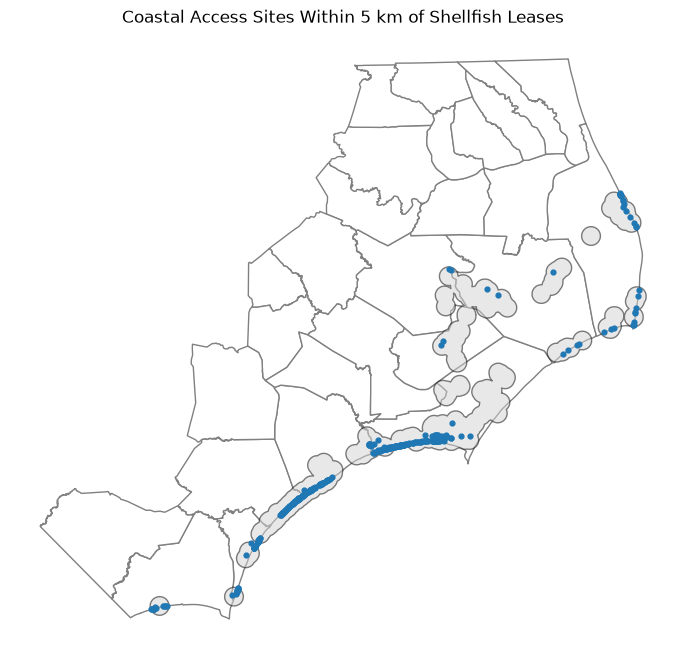

In [106]:
fig, ax = plt.subplots(figsize=(10, 8))

counties_proj.plot(ax=ax, facecolor="white", edgecolor="gray")

lease_buffer_area.plot(ax=ax, facecolor="lightgray", edgecolor="black", alpha=0.5)

access_near_leases.plot(ax=ax, markersize=12)

ax.set_title("Coastal Access Sites Within 5 km of Shellfish Leases")
ax.set_axis_off()

plt.show()

This map shows public coastal access sites located within 5 kilometers of shellfish lease areas. I projected the shellfish lease and coastal access layers to NAD83 / North Carolina (EPSG:32119) so distance could be measured in meters. I then made a 5,000-meter buffer around the shellfish lease polygons, and then clipped the coastal access sites to those buffer areas. Of the 799 coastal access sites located in counties containing shellfish leases, 377 are within 5 kilometers of a lease. This shows that a substantial portion of coastal access locations are located near shellfish aquaculture areas, while others remain farther away.

# **Saving the New Layers**

In [107]:
leases_by_county.to_file("../week07/data/leases_by_county.geojson", driver="GeoJSON")

access_in_lease_counties.to_file("../week07/data/access_in_lease_counties.geojson", driver="GeoJSON")

access_near_leases.to_crs(epsg=4326).to_file("../week07/data/access_near_leases.geojson", driver="GeoJSON")